# A mathematical approach of the evolutionary trajectories of a genome

## Two genes simulation with a simple Yule model

We consider the joint evolution of two gene families, denoted $x_1$ and $x_2$, evolving within a single species tree. The species tree is generated under a simple Yule model (pure birth process, no extinction) and is kept small to allow exhaustive inspection of the resulting gene trees.

The two gene families are strictly coupled at the level of speciation. Every bifurcation in the species tree simultaneously triggers a speciation in both $x_1$ and $x_2$, so that each daughter species inherits one copy of each gene. As a result, in the absence of duplication, both gene trees are topologically identical to the species tree.

Divergence between the two families arises exclusively through duplication events, which are modelled as a joint probabilistic decision taken along each branch of the species tree. Three outcomes are possible:

- Only $x_1$ duplicates — with probability *p_dup_x1*.

- Only $x_2$ duplicates — with probability *p_dup_x2*.

- Both $x_1$ and $x_2$ duplicate simultaneously — with a smaller probability *p_dup_both*.

The remaining probability mass corresponds to no duplication on that branch. Whenever a duplication occurs, the affected lineage is split into two descendants that remain within the same species node, in contrast to speciation, where the descendants are distributed across the daughter species.

This model provides a minimal but expressive framework for studying coupled gene family evolution: it isolates the effect of duplications as the sole source of topological disagreement between the two gene trees, while enforcing a shared speciation backbone. It also introduces an explicit form of correlated duplication, allowing the two families to co-expand at the same evolutionary time — a scenario commonly observed in real genomes, where tandem or whole-genome duplications affect multiple loci simultaneously.

Species tree:
(((((8:0.5080460090019523,9:0.5080460090019523)7:0.03026007761300409,6:0.5383060866149564)5:0.07791799555873302,4:0.6162240821736894)3:0.04304602953597758,2:0.659270111709667)1:0.340729888290333)0:0.0;


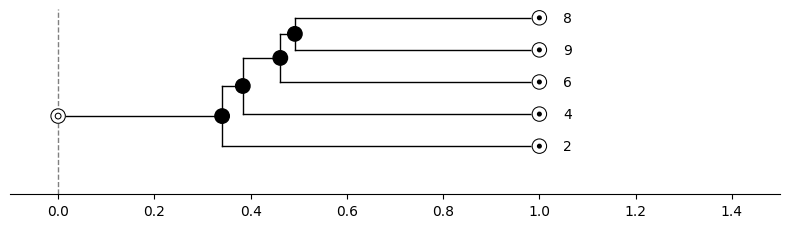

In [76]:
import random
import asymmetree.treeevolve as te
import asymmetree.visualization.tree_vis as tv
from asymmetree.utils.phylogenetic_trees import to_newick
from tralda.datastructures import Tree, TreeNode

# 1. Species tree (Yule model, 5 leaves, no extinction)

n_species = 5
tree_age = 1.0
birth_rate = 1.0

species_tree = te.species_tree_n_age(n_species, tree_age, birth_rate=birth_rate)
print("Species tree:")
print(to_newick(species_tree))
tv.visualize(species_tree, save_as="species_tree.pdf")

This tree is the backbone along which both gene families ($x_1$ and $x_2$) will evolve. The speciation events in this tree will be mirrored by both gene families. Every node in both gene trees must be created with the same three attributes.

Then, we add duplication events. This turns one gene lineage into two, both staying in the same species node. A duplication makes the tree binary (two descendants from one ancestor). The original lineage is replaced by $c_1$ (the surviving original copy), while $c_2$ (the duplicate) is appended to the lineage list.

In [77]:
# 2. Helper functions

def make_gene_node(label, species_node, dist=None):
    """Create a gene tree node associated with a species node."""
    node = TreeNode(label=label)
    node.species = species_node
    if dist is None:
        dist = getattr(species_node, "dist", None)
        if dist is None or dist <= 0:
            dist = random.uniform(0.05, 0.2)
    node.dist = dist
    return node


def apply_duplication(lineages, idx, species_node, family):
    """
    Duplicate a gene lineage.
    Two children are created in the SAME species node (this is what
    distinguishes a duplication from a speciation).
    """
    gene_node, _ = lineages[idx]
    dist = getattr(species_node, "dist", None)
    if dist is None or dist <= 0:
        dist = random.uniform(0.05, 0.2)

    c1 = make_gene_node(f"{family}_{species_node.label}_orig", species_node, dist)
    c2 = make_gene_node(f"{family}_{species_node.label}_dup",  species_node, dist)
    gene_node.add_child(c1)
    gene_node.add_child(c2)
    gene_node.event = "D"

    # Original lineage continues as c1; c2 is a new lineage.
    lineages[idx] = (c1, species_node)
    lineages.append((c2, species_node))


def apply_speciation(lineages, idx, species_children, family):
    """
    Split a gene lineage into copies for each species child.
    Every child of the species node receives its own copy of the gene.
    """
    gene_node, _ = lineages[idx]
    new_entries = []
    for child_sp in species_children:
        dist = getattr(child_sp, "dist", None)
        if dist is None or dist <= 0:
            dist = random.uniform(0.05, 0.2)
        c = make_gene_node(f"{family}_{child_sp.label}", child_sp, dist)
        gene_node.add_child(c)
        new_entries.append((c, child_sp))
    gene_node.event = "S"

    # Replace the original lineage with the first child; append the rest.
    lineages[idx] = new_entries[0]
    for ne in new_entries[1:]:
        lineages.append(ne)

Each family starts with one ancestral gene at the species root and maintains its own list of active lineages. One single random number is drawn per species node. Depending on which interval it falls into, we get one of four outcomes:

- If $[0, p_{x_1})$, then only $x_1$ duplicates.
- If $[p_{x_1}, p_{x_1}+p_{x_2})$, then only $x_2$ duplicates.
- If $[p_{x_1}+p_{x_2}, p_{x_1}+p_{x_2}+p_{x_1, x_2})$, then	both duplicate.
- Otherwise, no duplications with a probability of	$1 - (\textit{sum of the previous ones})$

 The newly-created duplicates also participate in the speciation that follows, giving each species child a copy of every copy.


--- Simulating coupled families x1 and x2 ---

  [speciation]  x1 and x2 speciated at species 0
  [speciation]  x1 and x2 speciated at species 1
  [speciation]  x1 and x2 speciated at species 3
  [duplication] x1 duplicated at species 5
  [speciation]  x1 and x2 speciated at species 5
  [speciation]  x1 and x2 speciated at species 7
  [duplication] x2 duplicated at species 8
  [duplication] x1 duplicated at species 4
  [duplication] x1 duplicated at species 2

Gene tree x1:
((((((x1_8:0.5080460090019523,x1_9:0.5080460090019523)x1_7:0.03026007761300409,x1_6:0.5383060866149564)x1_5_orig:0.07791799555873302,((x1_8:0.5080460090019523,x1_9:0.5080460090019523)x1_7:0.03026007761300409,x1_6:0.5383060866149564)x1_5_dup:0.07791799555873302)x1_5:0.07791799555873302,(x1_4_orig:0.6162240821736894,x1_4_dup:0.6162240821736894)x1_4:0.6162240821736894)x1_3:0.04304602953597758,(x1_2_orig:0.659270111709667,x1_2_dup:0.659270111709667)x1_2:0.659270111709667)x1_1:0.340729888290333)x1_root:0.0;

Gene tree x

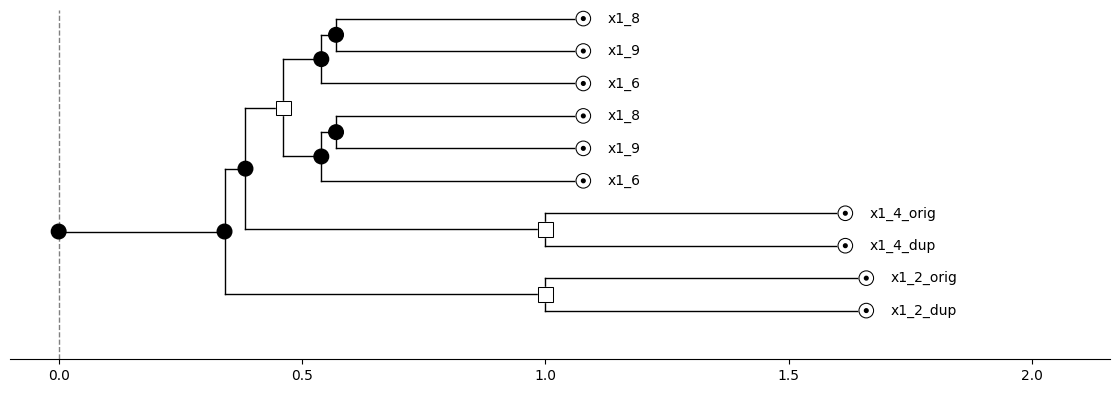

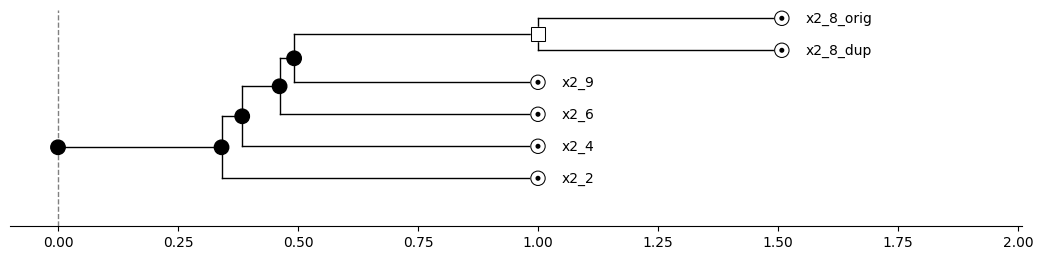

In [78]:
# 3. Coupled simulation of x1 and x2

def simulate_coupled_families(species_tree,
                              p_dup_x1=0.10,
                              p_dup_x2=0.10,
                              p_dup_both=0.03,
                              verbose=True):
    """
    Simulate two coupled gene families (x1 and x2).

    Rules:
      * Every speciation in the species tree ALWAYS triggers speciation
        in BOTH genes.
      * Along each branch, a joint duplication roll happens:
          - p_dup_x1   : only x1 duplicates
          - p_dup_x2   : only x2 duplicates
          - p_dup_both : both duplicate simultaneously
          - remaining  : no duplication at all
    """
    # Initialize both families at the species root
    root_x1 = TreeNode(label="x1_root"); root_x1.dist = 0.0
    root_x1.species = species_tree.root
    tree_x1 = Tree(root_x1)

    root_x2 = TreeNode(label="x2_root"); root_x2.dist = 0.0
    root_x2.species = species_tree.root
    tree_x2 = Tree(root_x2)

    lineages_x1 = [(root_x1, species_tree.root)]
    lineages_x2 = [(root_x2, species_tree.root)]

    # Preorder traversal of the species tree
    
    for M in species_tree.preorder():

        # 1) Joint duplication decision at species node M
        roll = random.random()
        dup_x1 = False
        dup_x2 = False
        if roll < p_dup_x1:
            dup_x1 = True
        elif roll < p_dup_x1 + p_dup_x2:
            dup_x2 = True
        elif roll < p_dup_x1 + p_dup_x2 + p_dup_both:
            dup_x1 = True
            dup_x2 = True

        if dup_x1:
            idxs = [i for i, (_, sp) in enumerate(lineages_x1) if sp == M]
            for i in reversed(idxs):
                apply_duplication(lineages_x1, i, M, "x1")
            if verbose:
                print(f"  [duplication] x1 duplicated at species {M.label}")

        if dup_x2:
            idxs = [i for i, (_, sp) in enumerate(lineages_x2) if sp == M]
            for i in reversed(idxs):
                apply_duplication(lineages_x2, i, M, "x2")
            if verbose:
                print(f"  [duplication] x2 duplicated at species {M.label}")

        # 2) Mandatory speciation (only if M is an internal node)
        
        if M.children:
            children = list(M.children)   # usually 2 children
            for family, lineages in [("x1", lineages_x1), ("x2", lineages_x2)]:
                idxs = [i for i, (_, sp) in enumerate(lineages) if sp == M]
                for i in reversed(idxs):
                    apply_speciation(lineages, i, children, family)
            if verbose:
                print(f"  [speciation]  x1 and x2 speciated at species {M.label}")

    # Finalize: mark leaves and ensure all dists are set
    for tree in (tree_x1, tree_x2):
        for leaf in tree.leaves():
            leaf.event = "S"
        for v in tree.preorder():
            if v.parent is not None:
                if not hasattr(v, "dist") or v.dist is None:
                    v.dist = random.uniform(0.05, 0.2)

    return tree_x1, tree_x2

# 4. Run the simulation

print("\n--- Simulating coupled families x1 and x2 ---\n")
tree_x1, tree_x2 = simulate_coupled_families(species_tree)

print("\nGene tree x1:")
print(to_newick(tree_x1, reconc=True))
tv.visualize(tree_x1, save_as="gene_x1.pdf")

print("\nGene tree x2:")
print(to_newick(tree_x2, reconc=True))
tv.visualize(tree_x2, save_as="gene_x2.pdf")

- The number of speciation events "$S$" in $x_1$ and $x_2$ should be identical (both follow the species tree's speciation structure).

- The number of duplication events "$D$" may differ, depending on which duplication rolls fired.

In [79]:
# 5. Event summary

def count_events(tree):
    counts = {"S": 0, "D": 0}
    for node in tree.preorder():
        if hasattr(node, "event") and node.event in counts:
            counts[node.event] += 1
    return counts

print("\nEvent summary:")
print("x1:", count_events(tree_x1))
print("x2:", count_events(tree_x2))


Event summary:
x1: {'S': 17, 'D': 3}
x2: {'S': 11, 'D': 1}


## Simulation for $n$ genes with a simple Yule model approach for single gene duplication events

Now, let's consider the joint evolution of an ordered set of distinct genes, $x_1, x_2, x_3, ... , x_n$, embedded in a genome whose linear order is explicitly tracked along a species tree. The species tree is generated under a simple Yule model and kept small to allow exhaustive inspection of the resulting gene trees.

Divergence between gene families arises exclusively through single-gene duplications, modelled as a probabilistic event that occurs along each branch of the species tree. When a gene duplicates, its copy is inserted into the ordered genome according to one of two mechanisms:

- Tandem duplication — with probability $p_\textit{tandem}$, the duplicate is placed immediately adjacent to the original gene, either before or after it in the sequence. For example: $x_1, x_2, x^d_2, x_3, ... , x_n$ or $x_1, x^d_2, x_2, x_3, ... , x_n$.

- Dispersed duplication — with probability $1−p_\textit{tandem}$, the duplicate is inserted at a random position in the genome, potentially far from the original.

We'll only one gene duplicates per event, in line with the requirement to avoid simultaneous multi-gene duplication scenarios. By tracking the genome as an ordered list, the model captures two biologically meaningful layers at once: the gene tree topology (who descends from whom) and the genomic architecture (where each gene copy physically resides).

Species tree:
(((4:0.4848262570139008,5:0.4848262570139008)3:0.13249284238515324,2:0.617319099399054)1:0.38268090060094595)0:0.0;


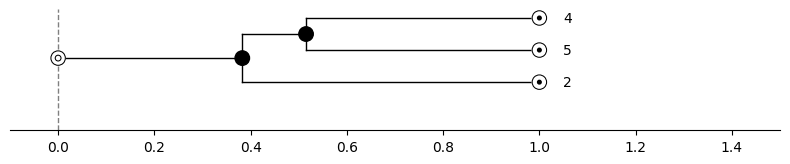

In [80]:
import random
import asymmetree.treeevolve as te
import asymmetree.visualization.tree_vis as tv
from asymmetree.utils.phylogenetic_trees import to_newick
from tralda.datastructures import Tree, TreeNode


# 1. Species tree (Yule model, 5 leaves, no extinction)

n_species = 3
tree_age = 1.0
birth_rate = 1.0

species_tree = te.species_tree_n_age(n_species, tree_age, birth_rate=birth_rate)
print("Species tree:")
print(to_newick(species_tree))
tv.visualize(species_tree, save_as="species_tree.pdf")

We create a species tree with just 3 leaves under the Yule model (pure birth, no extinction).

- *n_genes*: size of the ancestral genome (how many distinct gene families start at the root).

- *p_dup*: per-branch probability that a duplication happens. Applied before the speciation step at each species node.

- *p_tandem*: conditional on a duplication occurring, the probability that it is a tandem event (inserted adjacent to the original). With $1 − p_\textit{tandem}$, the duplication is dispersed (inserted at a random position).

The genome is not just a set of genes; it is an ordered list. This ordering is essential for modeling tandem duplications (which insert adjacent to the original).

In [81]:
# 2. Parameters

n_genes = 4          # number of initial gene families: x1, x2, ..., xn
p_dup = 0.4          # probability of a duplication on a given branch
p_tandem = 0.6       # conditional on duplication: prob. of tandem (adjacent)


# 3. Helper: create a gene node with all required attributes

def make_gene_node(label, species_node, event=None):
    node = TreeNode(label=str(label))          # <-- FIX: force string
    node.species = species_node
    dist = getattr(species_node, "dist", None)
    if dist is None or dist <= 0:
        dist = random.uniform(0.05, 0.2)
    node.dist = dist
    if event is not None:
        node.event = event
    return node

# 4. Initialize the ancestral genome as an ordered list of genes

initial_genome = []
gene_roots = {}
for k in range(1, n_genes + 1):
    label = f"x{k}"
    root = TreeNode(label=str(label))          # <-- FIX: force string
    root.species = species_tree.root
    root.dist = 0.0
    gene_roots[label] = root
    initial_genome.append((root, species_tree.root))

print(f"\nAncestral genome: [{' , '.join(gene_roots.keys())}]")


Ancestral genome: [x1 , x2 , x3 , x4]


We apply a coupled simulation loop. It walks the species tree in preorder (root → leaves) and, at each species node $M$, induces duplications and speciations. The genome is shown as a dictionary that will store the ordered genome for every species node. Duplication is applied before speciation. This means that if a gene duplicates at node $M$, both the original and the duplicate get carried into every daughter species by the speciation step. So a duplication at an internal node produces a duplication inherited by all descendant species.

- The tandem case inserts *c_dup* either immediately before ($i - 1$) or immediately after ($i + 1$) the original.

- The dispersed case picks a random insertion point $pos \in [0, len(current)]$, allowing the duplicate to land anywhere — including the beginning or end of the chromosome.

In [82]:
# 5. Simulate along the species tree (preorder traversal)

genomes = {species_tree.root: initial_genome}

for M in species_tree.preorder():

    # ---------- Retrieve the genome at node M ----------
    if M == species_tree.root:
        current = list(initial_genome)
    else:
        current = list(genomes[M])

    # ---------- Duplication phase (single-gene duplication) ----------
    if current and random.random() < p_dup:
        i = random.randrange(len(current))
        gene_node, _ = current[i]

        c_orig = make_gene_node(f"{gene_node.label}_orig", M)
        c_dup = make_gene_node(f"{gene_node.label}_dup", M)
        gene_node.add_child(c_orig)
        gene_node.add_child(c_dup)
        gene_node.event = "D"

        # The original copy keeps its position
        current[i] = (c_orig, M)

        # Decide where the duplicate is inserted
        if random.random() < p_tandem:
            if random.random() < 0.5:
                current.insert(i, (c_dup, M))
                mode = "tandem-before"
            else:
                current.insert(i + 1, (c_dup, M))
                mode = "tandem-after"
        else:
            pos = random.randrange(len(current) + 1)
            current.insert(pos, (c_dup, M))
            mode = f"dispersed (pos {pos})"

        print(f"  [D] {gene_node.label} duplicated at species {M.label} "
              f"-> {mode}")

    # Speciation phase (mandatory for every gene)
    if M.children:
        for daughter in M.children:
            new_genome = []
            for gene_node, _ in current:
                c = make_gene_node(daughter.label, daughter)
                gene_node.add_child(c)
                gene_node.event = "S"
                new_genome.append((c, daughter))
            genomes[daughter] = new_genome
    else:
        genomes[M] = current

  [D] 3 duplicated at species 3 -> dispersed (pos 2)
  [D] 2 duplicated at species 2 -> dispersed (pos 2)


All families share the same number of $S$ events up to the point where duplications add extra $S$ events (since every duplicated copy also undergoes subsequent speciations). $D$ counts differ across families: a family that duplicates more often has more internal duplication nodes.


--- Ordered genomes at extant species ---
  4: [4 , 4 , 4 , 4 , 4]
  5: [5 , 5 , 5 , 5 , 5]
  2: [2 , 2_orig , 2_dup , 2 , 2]

Gene tree for family x1:
(((4:0.4848262570139008,5:0.4848262570139008)3:0.13249284238515324,2:0.617319099399054)1:0.38268090060094595)x1:0.0;

Gene tree for family x2:
(((4:0.4848262570139008,5:0.4848262570139008)3:0.13249284238515324,(2_orig:0.617319099399054,2_dup:0.617319099399054)2:0.617319099399054)1:0.38268090060094595)x2:0.0;

Gene tree for family x3:
(((4:0.4848262570139008,5:0.4848262570139008)3:0.13249284238515324,2:0.617319099399054)1:0.38268090060094595)x3:0.0;

Gene tree for family x4:
((((4:0.4848262570139008,5:0.4848262570139008)3_orig:0.13249284238515324,(4:0.4848262570139008,5:0.4848262570139008)3_dup:0.13249284238515324)3:0.13249284238515324,2:0.617319099399054)1:0.38268090060094595)x4:0.0;

--- Event summary per family ---
  x1: {'S': 6, 'D': 0}
  x2: {'S': 7, 'D': 1}
  x3: {'S': 6, 'D': 0}
  x4: {'S': 9, 'D': 1}


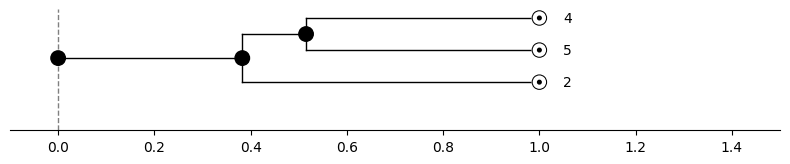

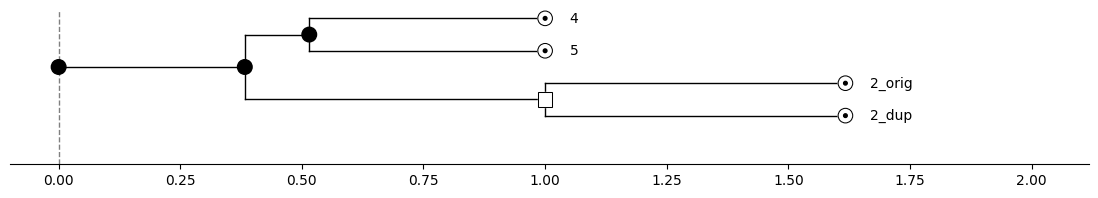

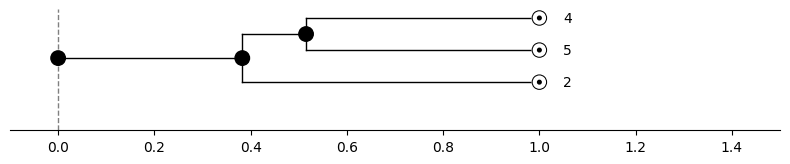

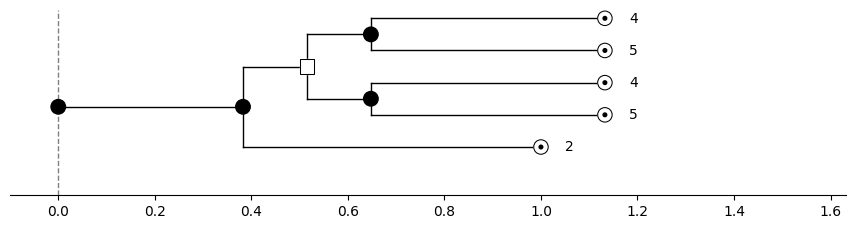

In [83]:
# 6. Finalize trees: ensure dists, mark extant leaves

gene_trees = {}
for label, root in gene_roots.items():
    tree = Tree(root)
    for v in tree.preorder():
        if v.parent is not None and (not hasattr(v, "dist") or v.dist is None):
            v.dist = random.uniform(0.05, 0.2)
        if not v.children:
            v.event = "S"
    gene_trees[label] = tree


# 7. Show the ordered genome at each extant species (leaf)

print("\n--- Ordered genomes at extant species ---")
for leaf in species_tree.leaves():
    genome = genomes[leaf]
    seq_str = " , ".join(str(node.label) for node, _ in genome)
    print(f"  {str(leaf.label)}: [{seq_str}]")


# 8. Print and visualize each gene tree

for label, tree in gene_trees.items():
    print(f"\nGene tree for family {label}:")
    print(to_newick(tree, reconc=True))
    tv.visualize(tree, save_as=f"gene_{label}.pdf")


# 9. Event summary per gene family

def count_events(tree):
    counts = {"S": 0, "D": 0}
    for v in tree.preorder():
        if hasattr(v, "event") and v.event in counts:
            counts[v.event] += 1
    return counts

print("\n--- Event summary per family ---")
for label, tree in gene_trees.items():
    print(f"  {label}: {count_events(tree)}")

In [84]:

# Summary: original genome vs final genomes

def genome_str(genome):
    return " , ".join(str(node.label) for node, _ in genome)

print("\n" + "=" * 60)
print("GENOME EVOLUTION SUMMARY")
print("=" * 60)
print(f"Original genome:       [{genome_str(initial_genome)}]")
print("-" * 60)
for leaf in species_tree.leaves():
    print(f"Final genome at {str(leaf.label)}: [{genome_str(genomes[leaf])}]")
print("=" * 60)


GENOME EVOLUTION SUMMARY
Original genome:       [x1 , x2 , x3 , x4]
------------------------------------------------------------
Final genome at 4: [4 , 4 , 4 , 4 , 4]
Final genome at 5: [5 , 5 , 5 , 5 , 5]
Final genome at 2: [2 , 2_orig , 2_dup , 2 , 2]


## Model for $n$ genes with block duplication events

An ordered genome of n distinct genes lives at the root of a Yule species tree. At every branch, a block duplication may occur (probability $p_\textit{dup}$), affecting a contiguous block whose length is drawn from a logarithmic distribution — making single-gene duplications overwhelmingly likely and whole-genome duplication effectively negligible. The duplicate block is inserted either tandem (adjacent to the original) or dispersed (at a random position), with large blocks increasingly pushed toward dispersal. Regardless of duplications, every speciation in the species tree forces every gene to speciate, preserving the genomic order in both daughter species. The result is a set of gene trees that share the species-tree backbone but differ in their internal duplication structure, together with an explicit genomic arrangement that evolves through time — a minimal yet expressive model of coupled gene-family evolution with realistic duplication dynamics.

Species tree:
(((4:0.17089597333583323,5:0.17089597333583323)3:0.5913409097095006,2:0.7622368830453338)1:0.23776311695466623)0:0.0;


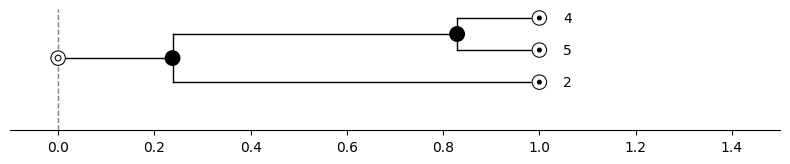

In [85]:
import random
import math
import asymmetree.treeevolve as te
import asymmetree.visualization.tree_vis as tv
from asymmetree.utils.phylogenetic_trees import to_newick
from tralda.datastructures import Tree, TreeNode


# 1. Species tree (Yule model, 5 leaves, no extinction)

n_species = 3
tree_age = 1.0
birth_rate = 1.0

species_tree = te.species_tree_n_age(n_species, tree_age, birth_rate=birth_rate)
print("Species tree:")
print(to_newick(species_tree))
tv.visualize(species_tree, save_as="species_tree.pdf")


# 2. Parameters

n_genes = 6          # size of the ancestral genome
p_dup = 0.5          # probability of a block duplication per branch
p_tandem = 0.85      # conditional: tandem vs dispersed
p_dispersed_block = 0.05  # extra weight toward dispersed for big blocks

As previously, we generate a random species tree with 3 leaves under the Yule model. There's a per-branch probability ($p_\textit{dup}$) that any block duplication happens. An exponential-decay parameter reduces the tandem probability for large blocks. For example, single-gene duplications have over ~44 % probabilities of occurrence, meanwhile, for a whole-genome duplication (l = 5) is rare (~9 %), and becomes exponentially rarer as the genome grows.

In [86]:
# 3. Logarithmic distribution for block length
#    P(l) ∝ 1/l   for l = 1, 2, ..., L_max

def sample_block_length(genome_size):
    """Sample a block length from a truncated logarithmic distribution."""
    if genome_size < 1:
        return 0
    weights = [1.0 / l for l in range(1, genome_size + 1)]
    return random.choices(range(1, genome_size + 1),
                          weights=weights, k=1)[0]


# 4. Helper: create a gene node with all required attributes

def make_gene_node(label, species_node, event=None):
    node = TreeNode(label=str(label))
    node.species = species_node
    dist = getattr(species_node, "dist", None)
    if dist is None or dist <= 0:
        dist = random.uniform(0.05, 0.2)
    node.dist = dist
    if event is not None:
        node.event = event
    return node


# 5. Initialize the ancestral genome as an ordered list

initial_genome = []
gene_roots = {}
for k in range(1, n_genes + 1):
    label = f"x{k}"
    root = TreeNode(label=str(label))
    root.species = species_tree.root
    root.dist = 0.0
    gene_roots[label] = root
    initial_genome.append((root, species_tree.root))

print(f"\nAncestral genome: [{' , '.join(gene_roots.keys())}]")


# 6. Simulate along the species tree

genomes = {species_tree.root: list(initial_genome)}   # seed the root

for M in species_tree.preorder():

    # ---------- Retrieve genome at node M ----------
    if M.parent is None:                              # root
        current = list(initial_genome)
    elif M in genomes:
        current = list(genomes[M])
    else:
        print(f"  [warning] no genome inherited for node {M.label}; "
              f"using empty genome")
        current = []

    # ---------- Block duplication phase ----------
    if current and random.random() < p_dup:

        # (a) sample block length from logarithmic distribution
        l = sample_block_length(len(current))

        # (b) sample a starting position for the contiguous block
        start = random.randrange(0, len(current) - l + 1)

        # (c) split every gene in the block into orig + dup children
        orig_block = []
        dup_block = []
        for k in range(l):
            gene_node, _ = current[start + k]
            c_orig = make_gene_node(f"{gene_node.label}_orig", M)
            c_dup = make_gene_node(f"{gene_node.label}_dup", M)
            gene_node.add_child(c_orig)
            gene_node.add_child(c_dup)
            gene_node.event = "D"
            orig_block.append((c_orig, M))
            dup_block.append((c_dup, M))

        # (d) replace the original block in-place
        current[start:start + l] = orig_block

        # (e) block-size-aware tandem probability
        p_tandem_eff = p_tandem * math.exp(-p_dispersed_block * l)

        if random.random() < p_tandem_eff:
            # tandem insertion: before or after the original block
            if random.random() < 0.5:
                current[start:start] = dup_block
                mode = "tandem-before"
            else:
                current[start + l:start + l] = dup_block
                mode = "tandem-after"
        else:
            # dispersed insertion at a random position
            pos = random.randrange(len(current) + 1)
            current[pos:pos] = dup_block
            mode = f"dispersed (pos {pos})"

        print(f"  [D] block of length l={l} (start={start}) duplicated "
              f"at species {M.label} -> {mode}")

    # ---------- Speciation phase (mandatory) ----------
    if M.children:
        for daughter in M.children:
            new_genome = []
            for gene_node, _ in current:
                c = make_gene_node(daughter.label, daughter)
                gene_node.add_child(c)
                gene_node.event = "S"
                new_genome.append((c, daughter))
            genomes[daughter] = new_genome
    else:
        genomes[M] = current


Ancestral genome: [x1 , x2 , x3 , x4 , x5 , x6]
  [D] block of length l=1 (start=0) duplicated at species 4 -> tandem-before
  [D] block of length l=3 (start=1) duplicated at species 5 -> dispersed (pos 3)
  [D] block of length l=3 (start=1) duplicated at species 2 -> tandem-after


The genome is a list, not a set. Order matters, because duplications insert new blocks at specific positions. At each node $M$, two phases occur: block duplication then speciation. The whole block is one joint duplication event, but its representation in the gene tree is a set of binary splits at $M$. We record every duplication event with its length, position, species node, and mode. Useful for tracing the history after a run.


GENOME EVOLUTION SUMMARY
Original genome:       [x1 , x2 , x3 , x4 , x5 , x6]
------------------------------------------------------------
Final genome at 4: [4_dup , 4_orig , 4 , 4 , 4 , 4 , 4]
Final genome at 5: [5 , 5_orig , 5_orig , 5_dup , 5_dup , 5_dup , 5_orig , 5 , 5]
Final genome at 2: [2 , 2_orig , 2_orig , 2_orig , 2_dup , 2_dup , 2_dup , 2 , 2]

Gene tree for family x1:
((((4_orig:0.17089597333583323,4_dup:0.17089597333583323)4:0.17089597333583323,5:0.17089597333583323)3:0.5913409097095006,2:0.7622368830453338)1:0.23776311695466623)x1:0.0;

Gene tree for family x2:
(((4:0.17089597333583323,(5_orig:0.17089597333583323,5_dup:0.17089597333583323)5:0.17089597333583323)3:0.5913409097095006,(2_orig:0.7622368830453338,2_dup:0.7622368830453338)2:0.7622368830453338)1:0.23776311695466623)x2:0.0;

Gene tree for family x3:
(((4:0.17089597333583323,(5_orig:0.17089597333583323,5_dup:0.17089597333583323)5:0.17089597333583323)3:0.5913409097095006,(2_orig:0.7622368830453338,2_dup:0.7622368

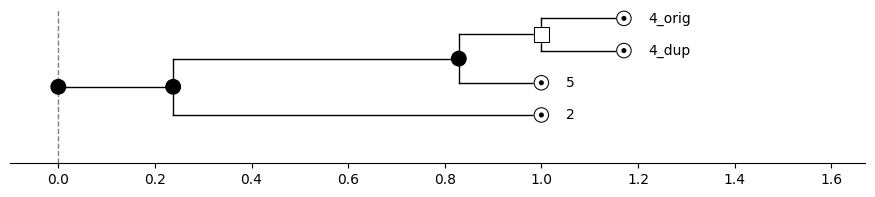

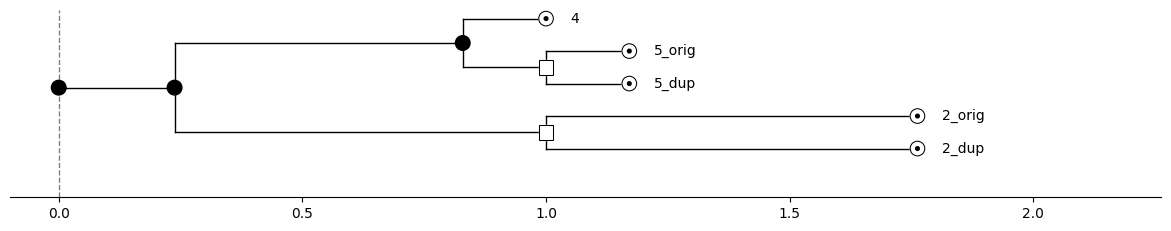

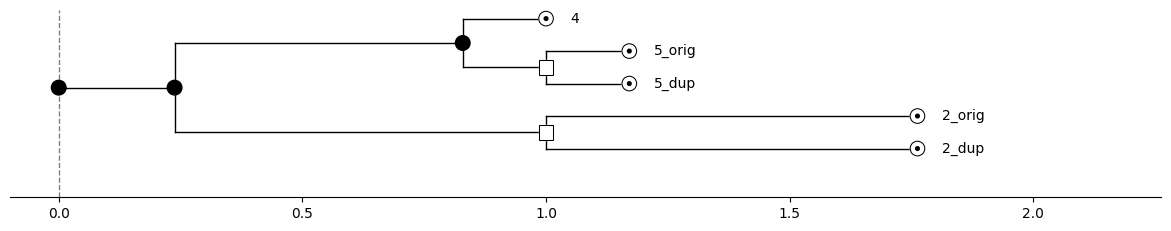

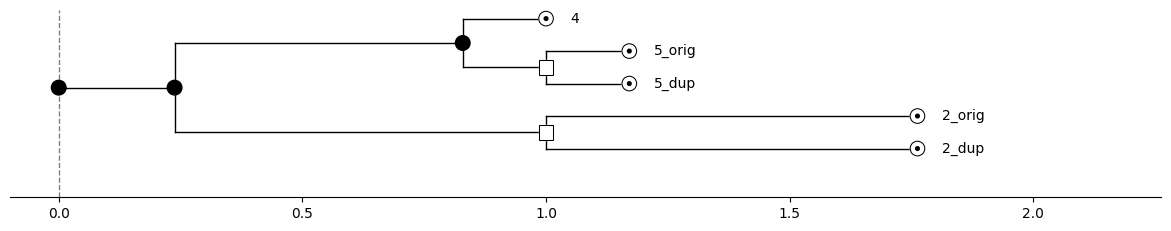

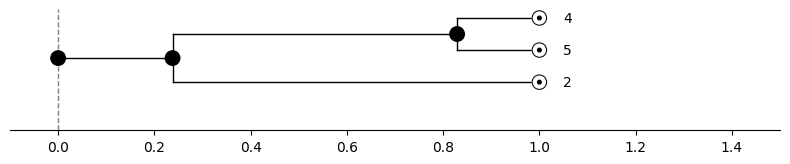

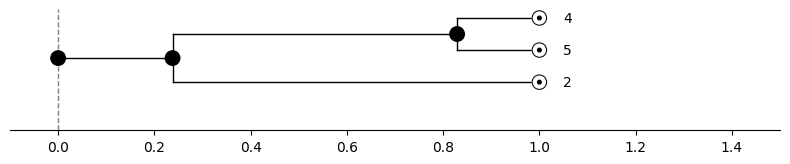

In [87]:
# 7. Finalize gene trees

gene_trees = {}
for label, root in gene_roots.items():
    tree = Tree(root)
    for v in tree.preorder():
        if v.parent is not None and (not hasattr(v, "dist") or v.dist is None):
            v.dist = random.uniform(0.05, 0.2)
        if not v.children:
            v.event = "S"
    gene_trees[label] = tree


# 8. Genome summary: original vs final

def genome_str(genome):
    return " , ".join(str(node.label) for node, _ in genome)

print("\n" + "=" * 60)
print("GENOME EVOLUTION SUMMARY")
print("=" * 60)
print(f"Original genome:       [{genome_str(initial_genome)}]")
print("-" * 60)
for leaf in species_tree.leaves():
    print(f"Final genome at {str(leaf.label)}: [{genome_str(genomes[leaf])}]")
print("=" * 60)


# 9. Print and visualize each gene tree

for label, tree in gene_trees.items():
    print(f"\nGene tree for family {label}:")
    print(to_newick(tree, reconc=True))
    tv.visualize(tree, save_as=f"gene_{label}.pdf")


# 10. Event summary per family

def count_events(tree):
    counts = {"S": 0, "D": 0}
    for v in tree.preorder():
        if hasattr(v, "event") and v.event in counts:
            counts[v.event] += 1
    return counts

print("\n--- Event summary per family ---")
for label, tree in gene_trees.items():
    print(f"  {label}: {count_events(tree)}")


Here we have a truncated logarithmic (log-series) distribution used to sample the length $\ell$ of duplicated genomic blocks, for a genome of 100 genes. The distribution is defined as $P(\ell) \propto 1/\ell$, normalized over $\ell = 1, 2, \dots, 100$ so that the probabilities sum to one.

$$P(\ell) = \frac{-\theta^{\ell}}{\ell \ln(1-\theta)}, \quad \theta \in (0,1)$$

is the **probability mass function (PMF)** of the **Fisher log-series distribution**, also called simply the **logarithmic distribution**. It is widely used in ecology (species abundance) and in genomics (gene family sizes, block duplication lengths).

For small $\ell$ (e.g., $\ell = 1$), both $\theta^\ell$ and $1/\ell$ are largest, so $P(1)$ is the **maximum** of the distribution. Single-gene duplications are always the most probable event. As $\ell$ grows, $\theta^\ell$ decays exponentially, and $1/\ell$ decays linearly. Their product produces a **heavy-tailed** distribution: long blocks are unlikely, but their probability is not zero (unlike a pure geometric distribution, which decays much faster).

The parameter $\theta$ controls **how fast the distribution decays**:

- $\theta \to 0$: the distribution is concentrated almost entirely on $\ell = 1$. Long blocks become effectively impossible.
- $\theta \to 1$: the tail becomes much heavier. Larger blocks (even whole-genome duplications) become non-negligible in probability.
- Typical values: $\theta \in [0.5, 0.99]$, depending on how strongly you want to favor small blocks.

The factor $-\ln(1-\theta)$ comes from the identity

$$
\sum_{\ell=1}^{\infty} \frac{\theta^{\ell}}{\ell} = -\ln(1-\theta),
$$

which guarantees that

$$
\sum_{\ell=1}^{\infty} P(\ell) = 1.
$$


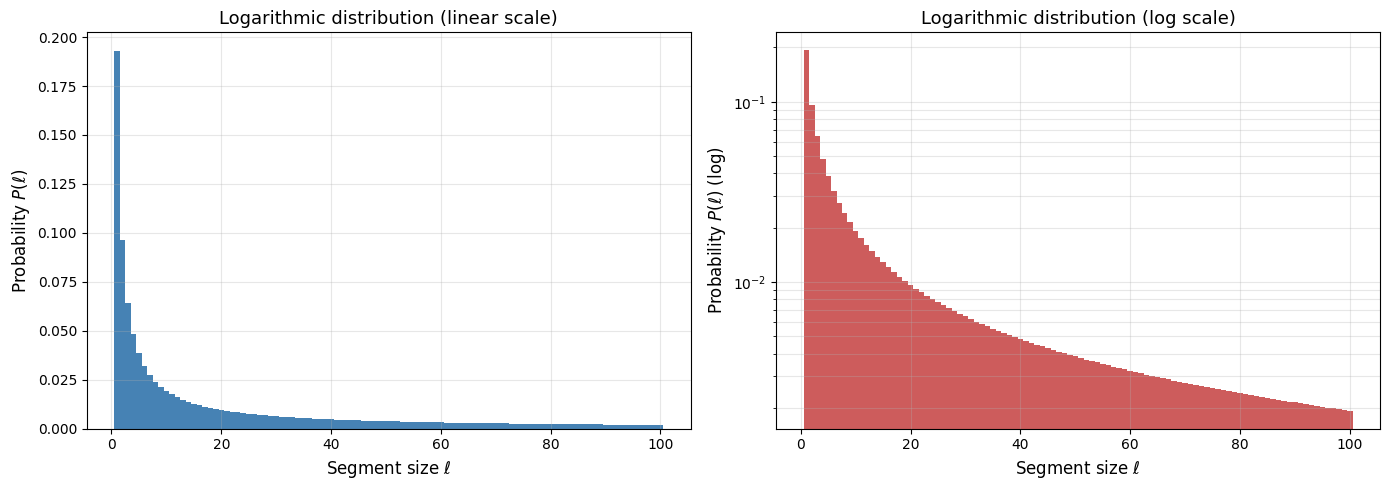

Probability summary for a genome of 100 genes:
  P(ℓ = 1)   = 0.1928  (19.28 %)
  P(ℓ = 2)   = 0.0964  (9.64 %)
  P(ℓ = 5)   = 0.0386  (3.86 %)
  P(ℓ = 10)  = 0.0193  (1.93 %)
  P(ℓ = 50)  = 0.003856  (0.3856 %)
  P(ℓ = 100) = 0.001928  (0.1928 %)


In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters

genome_size = 100

# Logarithmic (log-series) distribution truncated to [1, genome_size]
#    P(l) ∝ 1/l

lengths = np.arange(1, genome_size + 1)
weights = 1.0 / lengths                       # ∝ 1/l
probabilities = weights / weights.sum()       # normalize to sum 1

# Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: linear scale ---
axes[0].bar(lengths, probabilities, width=1.0,
            color="steelblue", edgecolor="none")
axes[0].set_xlabel("Segment size $\\ell$", fontsize=12)
axes[0].set_ylabel("Probability $P(\\ell)$", fontsize=12)
axes[0].set_title("Logarithmic distribution (linear scale)", fontsize=13)
axes[0].grid(alpha=0.3)

# --- Right panel: log scale on Y ---
axes[1].bar(lengths, probabilities, width=1.0,
            color="indianred", edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_xlabel("Segment size $\\ell$", fontsize=12)
axes[1].set_ylabel("Probability $P(\\ell)$ (log)", fontsize=12)
axes[1].set_title("Logarithmic distribution (log scale)", fontsize=13)
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("logarithmic_distribution_100.pdf", dpi=150)
plt.show()

# Numerical summary

print("Probability summary for a genome of 100 genes:")
print(f"  P(ℓ = 1)   = {probabilities[0]:.4f}  ({probabilities[0]*100:.2f} %)")
print(f"  P(ℓ = 2)   = {probabilities[1]:.4f}  ({probabilities[1]*100:.2f} %)")
print(f"  P(ℓ = 5)   = {probabilities[4]:.4f}  ({probabilities[4]*100:.2f} %)")
print(f"  P(ℓ = 10)  = {probabilities[9]:.4f}  ({probabilities[9]*100:.2f} %)")
print(f"  P(ℓ = 50)  = {probabilities[49]:.6f}  ({probabilities[49]*100:.4f} %)")
print(f"  P(ℓ = 100) = {probabilities[99]:.6f}  ({probabilities[99]*100:.4f} %)")